In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Load the dataset**

In [30]:
df=pd.read_csv("movie_ratings_project.csv")
print(df)

                               Title  Year      Genre  Rating
0           The Shawshank Redemption  1994      Drama     9.3
1                      The Godfather  1972      Crime     9.2
2                    The Dark Knight  2008     Action     9.0
3              The Godfather Part II  1974      Crime     9.0
4                       12 Angry Men  1957      Drama     9.0
..                               ...   ...        ...     ...
99                         Gone Girl  2014   Thriller     8.1
100               The Usual Suspects  1995    Mystery     8.5
101  The Girl with the Dragon Tattoo  2011    Mystery     7.8
102                       The Batman  2022     Action     7.8
103                      Oppenheimer  2023  Biography     8.6

[104 rows x 4 columns]


In [31]:
df.head(10)

,Title,Year,Genre,Rating
0,The Shawshank Redemption,1994,Drama,9.3
1,The Godfather,1972,Crime,9.2
2,The Dark Knight,2008,Action,9.0
3,The Godfather Part II,1974,Crime,9.0
4,12 Angry Men,1957,Drama,9.0
5,Schindler's List,1993,Drama,9.0
6,The Lord of the Rings,2003,Adventure,8.9
7,Pulp Fiction,1994,Crime,8.9
8,The Good the Bad and the Ugly,1966,Western,8.8
9,Forrest Gump,1994,Drama,8.8


In [32]:
df.shape

(104, 4)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Title   104 non-null    object 
 1   Year    104 non-null    int64  
 2   Genre   104 non-null    object 
 3   Rating  104 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.4+ KB


**Understand the dataset**

In [34]:
df.describe()

,Year,Rating
count,104.000000,104.000000
mean,2002.269231,8.250962
std,16.571839,0.445254
min,1936.000000,7.200000
25%,1995.000000,7.900000
50%,2007.000000,8.300000
75%,2014.000000,8.500000
max,2023.000000,9.300000


**Clean and preprocess the data**

In [35]:
#check missing values
df.isnull().sum()

Title     0
Year      0
Genre     0
Rating    0
dtype: int64

In [36]:
#check duplicate records
df.duplicated().sum()

np.int64(0)

In [37]:
#Remove duplicates
df = df.drop_duplicates()

In [38]:
#check data types
df.dtypes

Title      object
Year        int64
Genre      object
Rating    float64
dtype: object

In [39]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

In [40]:
df = df.dropna(subset=["Title", "Genre", "Rating"])

In [41]:
df.isnull().sum()

Title     0
Year      0
Genre     0
Rating    0
dtype: int64

**Calculate Mean,Median and Mode**

In [42]:
#Mean
mean_rating = df["Rating"].mean()
print("Mean Rating:", mean_rating)

Mean Rating: 8.250961538461537


In [43]:
#median
median_rating = df["Rating"].median()
print("Median Rating:", median_rating)


Median Rating: 8.3


In [44]:
#Mode
mode_rating = df["Rating"].mode()[0]
print("Mode Rating:", mode_rating)

Mode Rating: 8.5


**Histogram of Ratings**

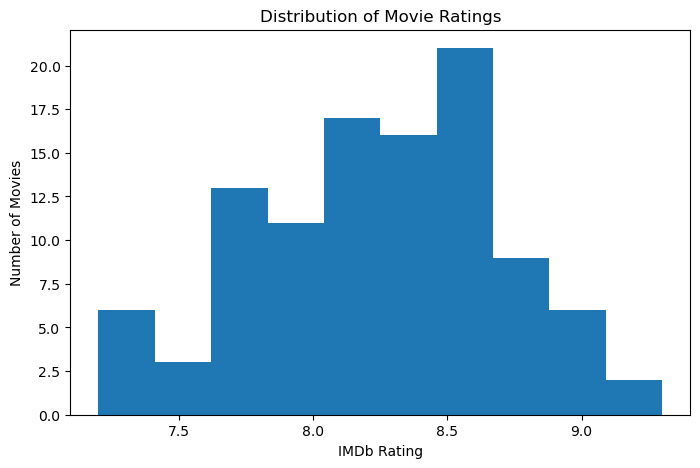

In [45]:
plt.figure(figsize=(8,5))

plt.hist(df["Rating"], bins=10)

plt.title("Distribution of Movie Ratings")
plt.xlabel("IMDb Rating")
plt.ylabel("Number of Movies")

plt.show()

**Box plot**

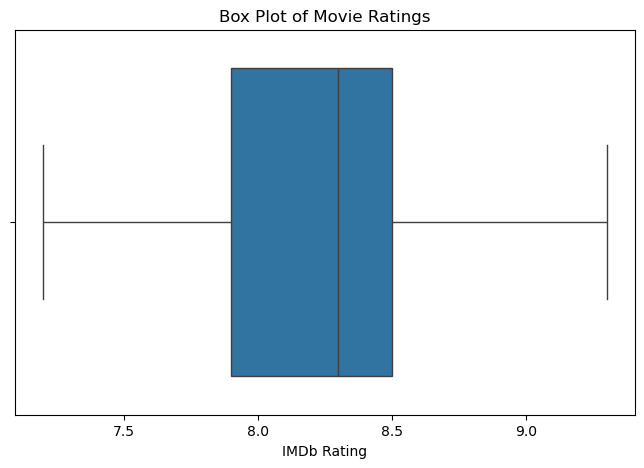

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Rating"])

plt.title("Box Plot of Movie Ratings")
plt.xlabel("IMDb Rating")

plt.show()

**Top-Rated movies**

In [47]:
top_movies = df.sort_values(
    by="Rating",
    ascending=False
).head(10)

top_movies[["Title", "Rating"]]

,Title,Rating
0,The Shawshank Redemption,9.3
1,The Godfather,9.2
2,The Dark Knight,9.0
3,The Godfather Part II,9.0
4,12 Angry Men,9.0
5,Schindler's List,9.0
6,The Lord of the Rings,8.9
7,Pulp Fiction,8.9
8,The Good the Bad and the Ugly,8.8
9,Forrest Gump,8.8


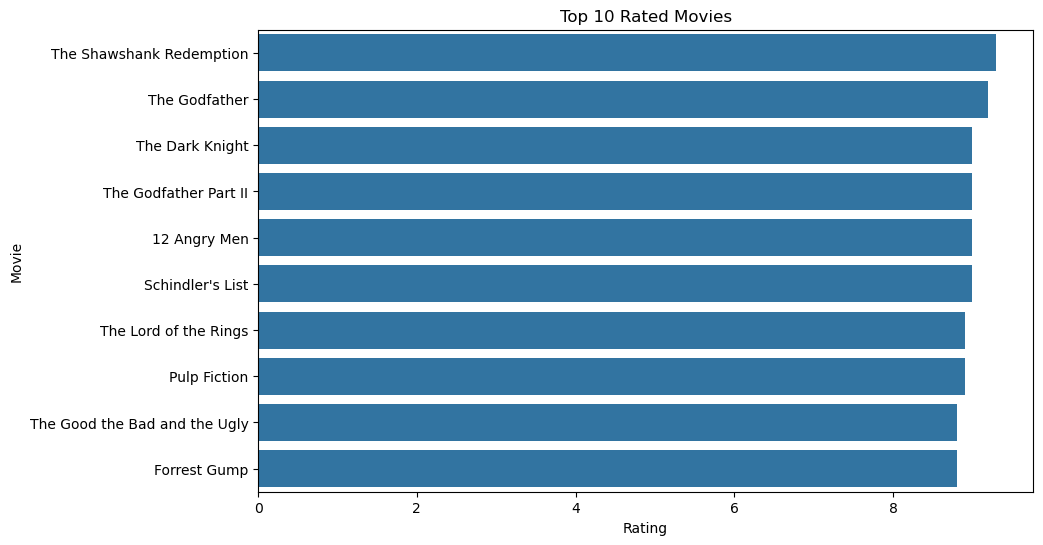

In [48]:
#Visualize them
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_movies,
    x="Rating",
    y="Title"
)

plt.title("Top 10 Rated Movies")
plt.xlabel("Rating")
plt.ylabel("Movie")

plt.show()

**Find top-rated geners**

In [49]:
genre_rating = df.groupby("Genre")["Rating"].mean().sort_values(ascending=False)

print(genre_rating)

Genre
Crime        8.687500
Western      8.600000
Drama        8.566667
War          8.500000
Adventure    8.400000
Animation    8.380000
Thriller     8.283333
Sci-Fi       8.228571
Action       8.185714
Mystery      8.160000
Sport        8.100000
Comedy       8.090000
Biography    8.080000
Musical      8.000000
Fantasy      8.000000
Romance      7.916667
Horror       7.800000
Name: Rating, dtype: float64


In [50]:
top_genres = genre_rating.head(10)

top_genres

Genre
Crime        8.687500
Western      8.600000
Drama        8.566667
War          8.500000
Adventure    8.400000
Animation    8.380000
Thriller     8.283333
Sci-Fi       8.228571
Action       8.185714
Mystery      8.160000
Name: Rating, dtype: float64

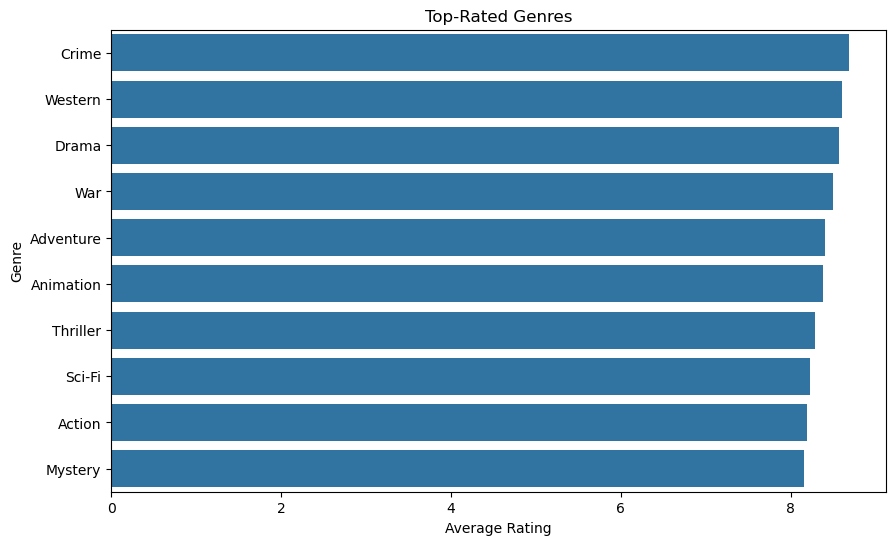

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top-Rated Genres")
plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.show()

**Dashboard**

C:\Users\a\AppData\Local\Temp\ipykernel_11692\1135206466.py:66: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


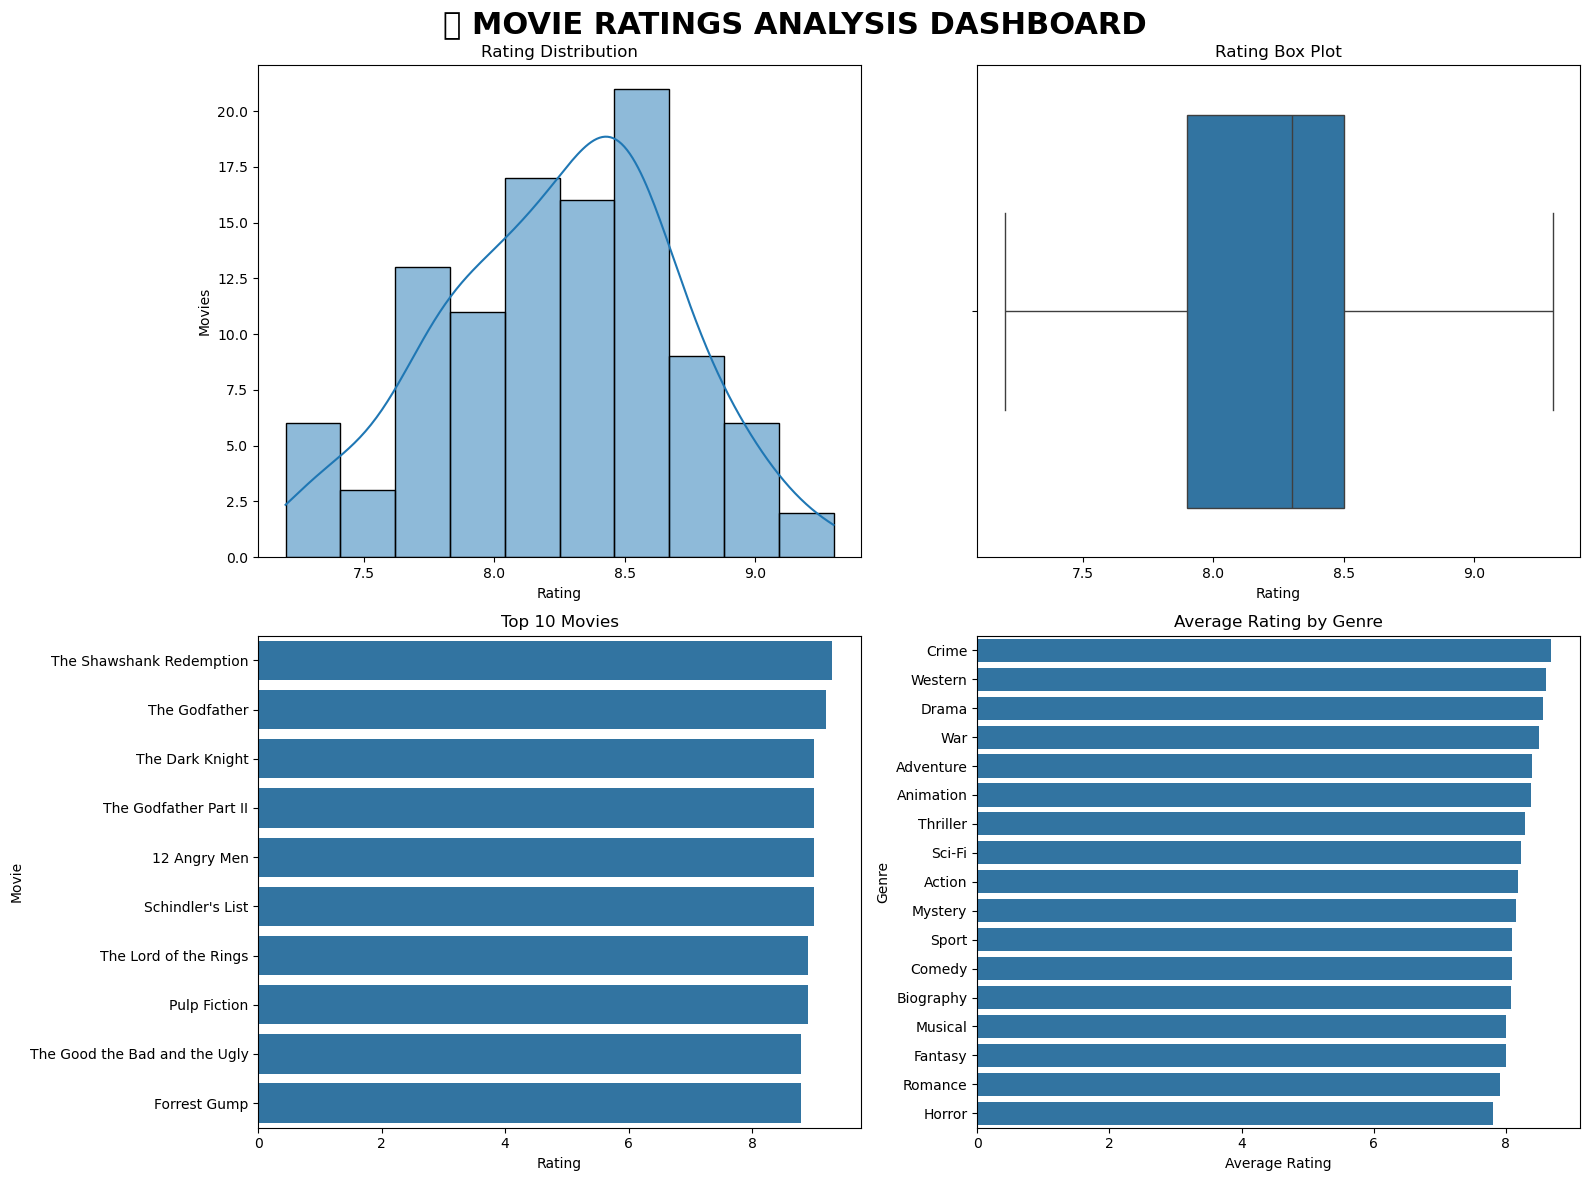

In [52]:
fig = plt.figure(figsize=(16, 12))

# Title
fig.suptitle(
    "🎬 MOVIE RATINGS ANALYSIS DASHBOARD",
    fontsize=22,
    fontweight="bold"
)

# 1. Rating Distribution
ax1 = plt.subplot(2, 2, 1)

sns.histplot(
    df["Rating"],
    bins=10,
    kde=True,
    ax=ax1
)

ax1.set_title("Rating Distribution")
ax1.set_xlabel("Rating")
ax1.set_ylabel("Movies")


# 2. Box Plot
ax2 = plt.subplot(2, 2, 2)

sns.boxplot(
    x=df["Rating"],
    ax=ax2
)

ax2.set_title("Rating Box Plot")
ax2.set_xlabel("Rating")


# 3. Top Movies
ax3 = plt.subplot(2, 2, 3)

sns.barplot(
    data=top_movies,
    x="Rating",
    y="Title",
    ax=ax3
)

ax3.set_title("Top 10 Movies")
ax3.set_xlabel("Rating")
ax3.set_ylabel("Movie")


# 4. Genres
ax4 = plt.subplot(2, 2, 4)

sns.barplot(
    x=genre_rating.values,
    y=genre_rating.index,
    ax=ax4
)

ax4.set_title("Average Rating by Genre")
ax4.set_xlabel("Average Rating")
ax4.set_ylabel("Genre")


plt.tight_layout()

plt.show()

In [53]:
print("=" * 50)
print("        MOVIE RATINGS DASHBOARD")
print("=" * 50)

print("Total Movies       :", len(df))
print("Mean Rating        :", round(mean_rating, 2))
print("Median Rating      :", round(median_rating, 2))
print("Mode Rating        :", mode_rating)
print("Highest Rating     :", df["Rating"].max())
print("Highest Rated Movie:", df.loc[df["Rating"].idxmax(), "Title"])

print("=" * 50)

        MOVIE RATINGS DASHBOARD
Total Movies       : 104
Mean Rating        : 8.25
Median Rating      : 8.3
Mode Rating        : 8.5
Highest Rating     : 9.3
Highest Rated Movie: The Shawshank Redemption
